In [13]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import os

In [14]:
dataset_path = r"C:\Users\Hp\Desktop\images_project"

train_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.3,
    subset="training",
    seed=123,
    image_size=(224, 224),
    batch_size=16
)

val_test_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.3,
    subset="validation",
    seed=123,
    image_size=(224, 224),
    batch_size=16
)

class_names = train_ds.class_names
print("Classes:", class_names)

val_size = int(0.5 * len(val_test_ds))
val_ds = val_test_ds.take(val_size)
test_ds = val_test_ds.skip(val_size)

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)

Found 600 files belonging to 3 classes.
Using 420 files for training.
Found 600 files belonging to 3 classes.
Using 180 files for validation.
Classes: ['dangerimages', 'isolatedimages', 'safeimages']


In [15]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.RandomBrightness(0.2),
])


In [16]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input

base_model = ResNet50(
    input_shape=(224,224,3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False

model = tf.keras.Sequential([
    data_augmentation,
    tf.keras.layers.Lambda(preprocess_input),   
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(3, activation='softmax')
])


In [17]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0003),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [18]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20
)

Epoch 1/20
27/27 [==============================] - 175s 5s/step - loss: 1.4097 - accuracy: 0.4000 - val_loss: 0.8920 - val_accuracy: 0.6042
Epoch 2/20
27/27 [==============================] - 130s 5s/step - loss: 1.1364 - accuracy: 0.4857 - val_loss: 0.8100 - val_accuracy: 0.6250
Epoch 3/20
27/27 [==============================] - 192s 7s/step - loss: 0.8592 - accuracy: 0.6476 - val_loss: 0.7206 - val_accuracy: 0.6771
Epoch 4/20
27/27 [==============================] - 166s 6s/step - loss: 0.7527 - accuracy: 0.6881 - val_loss: 0.7379 - val_accuracy: 0.6979
Epoch 5/20
27/27 [==============================] - 222s 8s/step - loss: 0.7117 - accuracy: 0.7214 - val_loss: 0.6270 - val_accuracy: 0.7292
Epoch 6/20
27/27 [==============================] - 151s 5s/step - loss: 0.6880 - accuracy: 0.7476 - val_loss: 0.6028 - val_accuracy: 0.7812
Epoch 7/20
27/27 [==============================] - 134s 5s/step - loss: 0.6053 - accuracy: 0.7524 - val_loss: 0.5125 - val_accuracy: 0.7604
Epoch 8/20
27

In [19]:
test_loss, test_acc = model.evaluate(test_ds)
print("Test Accuracy:", test_acc)

6/6 [==============================] - 14s 2s/step - loss: 0.5148 - accuracy: 0.7738
Test Accuracy: 0.773809552192688


1/1 [==============================] - 6s 6s/step


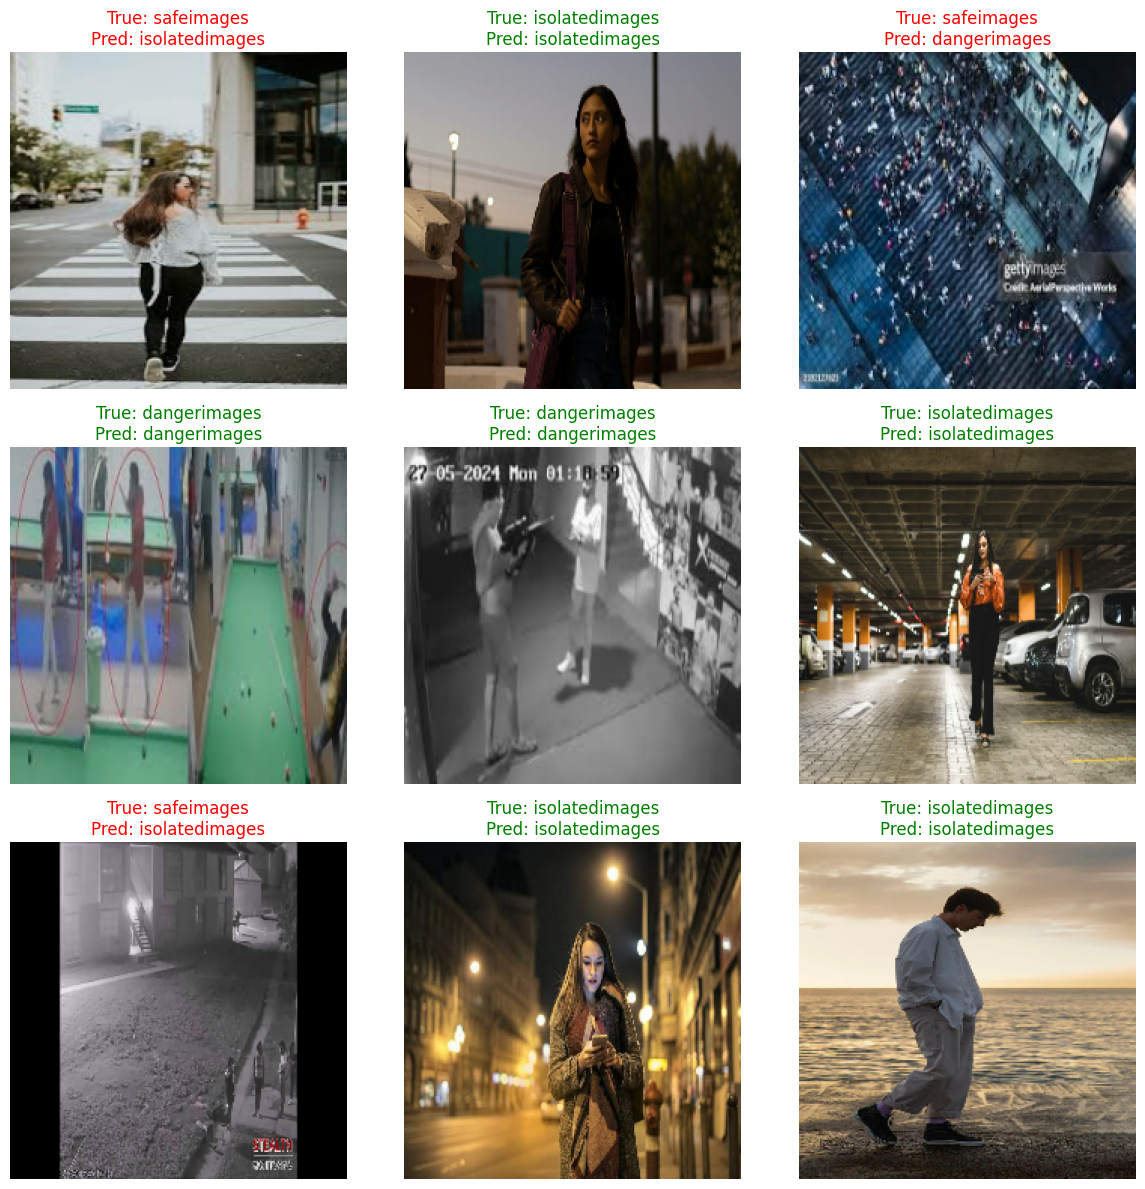

In [20]:
plt.figure(figsize=(12,12))

batch = next(iter(test_ds))
images, labels = batch

predictions = model.predict(images)
predicted_labels = np.argmax(predictions, axis=1)

for i in range(9):
    plt.subplot(3,3,i+1)
    img = images[i].numpy().astype("uint8")

    plt.imshow(img)

    true_label = class_names[labels[i]]
    pred_label = class_names[predicted_labels[i]]

    color = "green" if true_label == pred_label else "red"

    plt.title(f"True: {true_label}\nPred: {pred_label}", color=color)
    plt.axis("off")

plt.tight_layout()
plt.show()



In [21]:
y_true = []
y_pred = []
y_score = []

for images, labels in test_ds:
    preds = model.predict(images)
    pred_labels = np.argmax(preds, axis=1)
    
    y_true.extend(labels.numpy())
    y_pred.extend(pred_labels)
    y_score.extend(preds)

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_score = np.array(y_score)

1/1 [==============================] - 1s 527ms/step


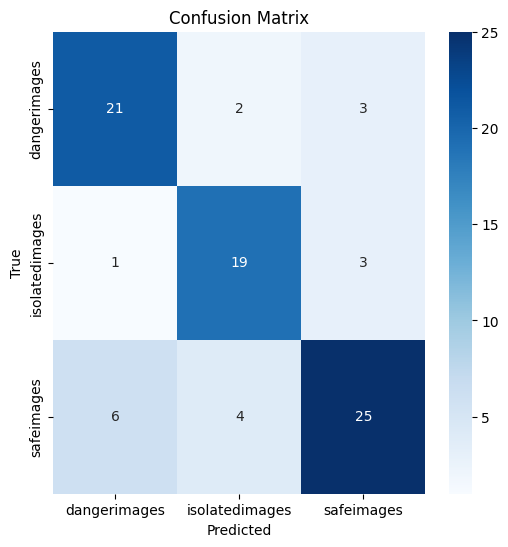

In [22]:
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6,6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

In [23]:
print("Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names))

Classification Report:

                precision    recall  f1-score   support

  dangerimages       0.75      0.81      0.78        26
isolatedimages       0.76      0.83      0.79        23
    safeimages       0.81      0.71      0.76        35

      accuracy                           0.77        84
     macro avg       0.77      0.78      0.78        84
  weighted avg       0.78      0.77      0.77        84



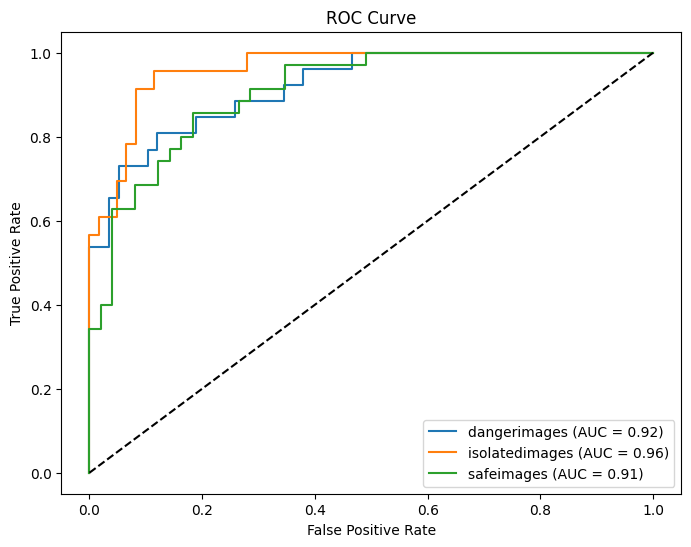

In [24]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

# Binarize the labels for multi-class ROC
y_true_bin = label_binarize(y_true, classes=range(len(class_names)))

plt.figure(figsize=(8,6))
for i, class_name in enumerate(class_names):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{class_name} (AUC = {roc_auc:.2f})')

plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()